# Genome Mining: Cluster Biosintético de Psilocibina en *Psilocybe cubensis*

Este notebook documenta el análisis completo: descarga del genoma de referencia,
identificación del cluster biosintético de psilocibina mediante homología (BLAST),
y visualización de los resultados.

**Genoma utilizado**: GCF_017499595.1 (cepa P.envy, McKernan et al. 2021)

In [1]:
from Bio import SeqIO

path = "../psilocybe_penvy/ncbi_dataset/data/GCF_017499595.1/GCF_017499595.1_MGC_Penvy_1_genomic.fna"

contigs = list(SeqIO.parse(path, "fasta"))

print(f"Número de contigs: {len(contigs)}")
print(f"Tamaño total del genoma: {sum(len(c.seq) for c in contigs):,} bp")

Número de contigs: 21
Tamaño total del genoma: 46,580,944 bp


In [2]:
import requests

accessions = {
    "PsiD": "P0DPA6",
    "PsiH": "P0DPA7",
    "PsiK": "P0DPA8",
    "PsiM": "P0DPA9",
}

with open("../referencias_psilocibina.fasta", "w") as out_file:
    for nombre, accession in accessions.items():
        url = f"https://rest.uniprot.org/uniprotkb/{accession}.fasta"
        response = requests.get(url)
        if response.status_code == 200:
            out_file.write(response.text)
            print(f"{nombre} ({accession}) descargado correctamente")

PsiD (P0DPA6) descargado correctamente
PsiH (P0DPA7) descargado correctamente
PsiK (P0DPA8) descargado correctamente
PsiM (P0DPA9) descargado correctamente


## Búsqueda de homología (BLAST)

Comparamos las secuencias de referencia contra el proteoma completo del genoma
descargado, para confirmar la presencia e identidad de los genes de la ruta
biosintética.

In [4]:
import subprocess
import os

os.makedirs("../blast_db", exist_ok=True)

# Construir la base de datos BLAST (si no existe ya)
subprocess.run([
    "makeblastdb",
    "-in", "../psilocybe_penvy/ncbi_dataset/data/GCF_017499595.1/protein.faa",
    "-dbtype", "prot",
    "-out", "../blast_db/penvy_proteins"
], check=True)

print("Base de datos BLAST construida correctamente")



Building a new DB, current time: 07/06/2026 23:45:02
New DB name:   /Users/enzo/Desktop/psilocybe-genome-mining/blast_db/penvy_proteins
New DB title:  ../psilocybe_penvy/ncbi_dataset/data/GCF_017499595.1/protein.faa
Sequence type: Protein
Deleted existing Protein BLAST database named /Users/enzo/Desktop/psilocybe-genome-mining/blast_db/penvy_proteins
Keep MBits: T
Maximum file size: 3000000000B
Adding sequences from FASTA; added 13330 sequences in 0.140982 seconds.




Critical: (310.5) External MBEDTLS version mismatch: 3.6.5 headers vs. 3.6.6 runtime


Base de datos BLAST construida correctamente


In [5]:
import pandas as pd

subprocess.run([
    "blastp",
    "-query", "../referencias_psilocibina.fasta",
    "-db", "../blast_db/penvy_proteins",
    "-out", "../resultados_blast.tsv",
    "-outfmt", "6 qseqid sseqid pident length evalue bitscore stitle",
    "-evalue", "1e-10"
], check=True)

columnas = ["query", "hit", "identidad", "longitud", "evalue", "bitscore", "descripcion"]
resultados = pd.read_csv("../resultados_blast.tsv", sep="\t", names=columnas)

# Mostrar solo los matches con 100% de identidad (los genes exactos)
resultados[resultados["identidad"] == 100.0]

Critical: (310.5) External MBEDTLS version mismatch: 3.6.5 headers vs. 3.6.6 runtime


,query,hit,identidad,longitud,evalue,bitscore,descripcion
0,sp|P0DPA6|PSID_PSICU,XP_047744498.1,100.0,439,0.0,917.0,XP_047744498.1 L-tryptophan decarboxylase [Psi...
8,sp|P0DPA7|PSIH_PSICU,XP_047744495.1,100.0,438,0.0,908.0,XP_047744495.1 Tryptamine 4-monooxygenase [Psi...
101,sp|P0DPA8|PSIK_PSICU,XP_047744494.1,100.0,362,0.0,759.0,XP_047744494.1 Major facilitator-type transpor...
103,sp|P0DPA9|PSIM_PSICU,XP_047744497.1,100.0,309,0.0,642.0,XP_047744497.1 Psilocybin synthase [Psilocybe ...


## Extracción de coordenadas y visualización del cluster

Con los genes identificados, extraemos su posición exacta en el genoma
(archivo GFF3) para confirmar su agrupación física y visualizar el cluster.

In [9]:
genes_confirmados = {
    "PsiD": "XP_047744498.1",
    "PsiH": "XP_047744495.1",
    "PsiK": "XP_047744494.1",
    "PsiM": "XP_047744497.1",
    "psiT2": "XP_047744496.1",
}

gff_path = "../psilocybe_penvy/ncbi_dataset/data/GCF_017499595.1/genomic.gff"

# Ahora guardamos una LISTA de posiciones por gen, no solo la primera
posiciones_por_gen = {nombre: [] for nombre in genes_confirmados}

with open(gff_path) as f:
    for linea in f:
        if linea.startswith("#"):
            continue
        campos = linea.strip().split("\t")
        if len(campos) < 9 or campos[2] != "CDS":
            continue

        for nombre, accession in genes_confirmados.items():
            if accession in campos[8]:
                inicio = int(campos[3])
                fin = int(campos[4])
                hebra = campos[6]
                posiciones_por_gen[nombre].append((inicio, fin, hebra))

# Ahora sí: tomamos el mínimo de todos los inicios y el máximo de todos los finales
coordenadas = {}
for nombre, posiciones in posiciones_por_gen.items():
    inicios = [p[0] for p in posiciones]
    fines = [p[1] for p in posiciones]
    hebra = posiciones[0][2]  # la hebra es la misma para todos los exones del gen
    coordenadas[nombre] = {
        "inicio": min(inicios),
        "fin": max(fines),
        "hebra": hebra,
    }

coordenadas

{'PsiD': {'inicio': 1676182, 'fin': 1677607, 'hebra': '-'},
 'PsiH': {'inicio': 1667511, 'fin': 1669282, 'hebra': '+'},
 'PsiK': {'inicio': 1663425, 'fin': 1667194, 'hebra': '+'},
 'PsiM': {'inicio': 1673493, 'fin': 1675081, 'hebra': '-'},
 'psiT2': {'inicio': 1670366, 'fin': 1672379, 'hebra': '-'}}

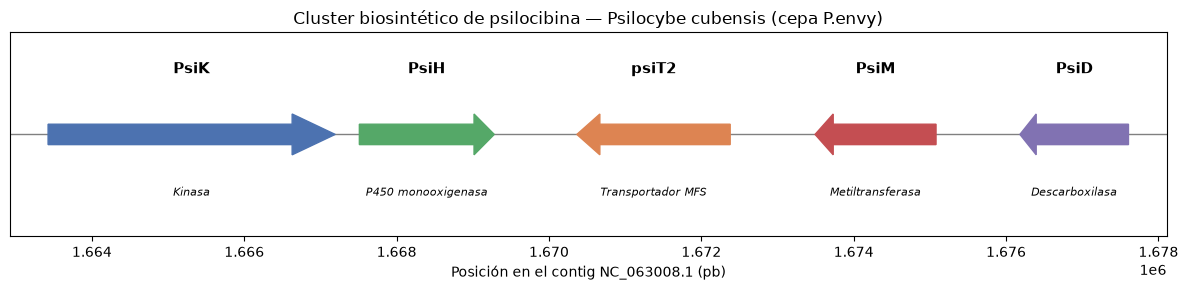

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

colores = {"PsiK": "#4C72B0", "PsiH": "#55A868", "psiT2": "#DD8452", "PsiM": "#C44E52", "PsiD": "#8172B2"}
productos = {"PsiK": "Kinasa", "PsiH": "P450 monooxigenasa", "psiT2": "Transportador MFS", "PsiM": "Metiltransferasa", "PsiD": "Descarboxilasa"}

fig, ax = plt.subplots(figsize=(12, 3))

inicio_min = min(c["inicio"] for c in coordenadas.values()) - 500
fin_max = max(c["fin"] for c in coordenadas.values()) + 500
ax.plot([inicio_min, fin_max], [0, 0], color="gray", linewidth=1, zorder=1)

for nombre, datos in coordenadas.items():
    ancho = datos["fin"] - datos["inicio"]
    direccion = 1 if datos["hebra"] == "+" else -1
    rect = patches.FancyArrow(
        datos["inicio"] if direccion == 1 else datos["fin"],
        0, ancho * direccion, 0,
        width=0.3, head_width=0.6, head_length=ancho * 0.15,
        length_includes_head=True, color=colores[nombre], zorder=2,
    )
    ax.add_patch(rect)
    centro = (datos["inicio"] + datos["fin"]) / 2
    ax.text(centro, 0.9, nombre, ha="center", fontsize=11, fontweight="bold")
    ax.text(centro, -0.9, productos[nombre], ha="center", fontsize=8, style="italic")

ax.set_xlim(inicio_min, fin_max)
ax.set_ylim(-1.5, 1.5)
ax.set_yticks([])
ax.set_xlabel("Posición en el contig NC_063008.1 (pb)")
ax.set_title("Cluster biosintético de psilocibina — Psilocybe cubensis (cepa P.envy)")
plt.tight_layout()
plt.show()